In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression, RidgeCV   # DÜZELTME 4: RidgeCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import shap

In [2]:
df = pd.read_csv("C:/Users/kerem/Desktop/EnerjiSon/claude/birlesik_veri.csv")
df = df.copy()
df["Datetime"] = pd.to_datetime(df["Datetime"])
df = df.sort_values("Datetime")
df = df.set_index("Datetime")

In [3]:
def evaluate(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    mae   = mean_absolute_error(y_true, y_pred)
    mape  = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-9))) * 100
    nrmse = rmse / (y_true.max() - y_true.min() + 1e-8) * 100
    smape = 100 * np.mean(
        2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-9)
    )
    return rmse, mae, mape, nrmse, smape

In [4]:
def evaluate_price(y_true, y_pred, min_price_threshold=10.0):
    """
    DÜZELTME 1b: Fiyat için özel metrik.
    Piyasada ≤10 TL/MWh olan saatler (gece yenilenebilir fazlası)
    MAPE ve SMAPE hesabından çıkarılır; bu saatlerde hata gerçekçi
    yüzde cinsinden ölçülemez.
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    nrmse = rmse / (y_true.max() - y_true.min() + 1e-8) * 100  # %

    # Sadece fiyat > threshold olan saatler için MAPE/SMAPE
    mask = y_true > min_price_threshold
    n_filtered = (~mask).sum()

    if mask.sum() == 0:
        mape_f = smape_f = float("nan")
    else:
        mape_f  = np.mean(
            np.abs((y_true[mask] - y_pred[mask]) / (y_true[mask] + 1e-9))
        ) * 100
        smape_f = 100 * np.mean(
            2 * np.abs(y_pred[mask] - y_true[mask])
            / (np.abs(y_true[mask]) + np.abs(y_pred[mask]) + 1e-9)
        )

    print(f"  RMSE  : {rmse:,.2f} TL")
    print(f"  MAE   : {mae:,.2f} TL")
    print(f"  NRMSE : {nrmse:.2f}%")
    print(f"  MAPE  : {mape_f:.2f}%  (>{min_price_threshold} TL saatler, {n_filtered} saat hariç)")
    print(f"  SMAPE : {smape_f:.2f}% (>{min_price_threshold} TL saatler)")
    return rmse, mae, mape_f, nrmse, smape_f

In [5]:
def evaluate_full(y_true, y_pred, label: str = "", eps: float = 10.0) -> dict:
    """
    ✅ Düzeltilmiş evaluate_full: eps=10.0 TL varsayılan.
    1-10 TL saatler artık MAPE'yi patlatmıyor.
    """
    import numpy as np
    from sklearn.metrics import mean_squared_error, mean_absolute_error

    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    yt, yp = y_true[mask], y_pred[mask]

    rmse  = np.sqrt(np.mean((yt - yp) ** 2))
    mae   = np.mean(np.abs(yt - yp))
    nrmse = rmse / (yt.max() - yt.min() + 1e-8) * 100

    # ✅ eps=10.0 — düşük fiyatlı saatler hariç
    safe  = np.abs(yt) > eps
    mape  = np.mean(np.abs((yt[safe] - yp[safe]) / yt[safe])) * 100 if safe.any() else float("nan")

    smape = np.mean(
        2 * np.abs(yt - yp) / (np.abs(yt) + np.abs(yp) + 1e-8)
    ) * 100

    thr        = np.percentile(yt, 95)
    spike_mask = yt > thr
    spike_rmse = (
        np.sqrt(np.mean((yt[spike_mask] - yp[spike_mask]) ** 2))
        if spike_mask.sum() > 0 else float("nan")
    )
    spike_smape = (
        np.mean(2 * np.abs(yt[spike_mask] - yp[spike_mask]) /
                (np.abs(yt[spike_mask]) + np.abs(yp[spike_mask]) + 1e-8)) * 100
        if spike_mask.sum() > 0 else float("nan")
    )

    if label:
        print(f"\n{'─'*55}")
        print(f" {label} — Tam Performans Raporu (eps={eps:.0f} TL filtresi)")
        print(f"{'─'*55}")
        print(f"  Toplam gözlem  : {len(yt):>8,}")
        print(f"  RMSE           : {rmse:>12,.2f}")
        print(f"  MAE            : {mae:>12,.2f}")
        print(f"  NRMSE          : {nrmse:>10.2f}%")
        print(f"  MAPE (|y|>{eps:.0f}): {mape:>10.2f}%  ({safe.sum():,} gözlem)")
        print(f"  sMAPE          : {smape:>10.2f}%")
        print(f"{'─'*55}")
        print(f"  Spike Analizi (üst %5, n={spike_mask.sum()}, eşik={thr:,.0f}):")
        print(f"    RMSE          : {spike_rmse:>12,.2f}")
        print(f"    sMAPE         : {spike_smape:>10.2f}%")
        print(f"{'─'*55}")
        n_filtered = (~safe).sum()
        if n_filtered > 0:
            print(f"  ⚠️  {n_filtered} saat ≤{eps:.0f} TL MAPE dışında tutuldu.")

    return {
        "RMSE": rmse, "MAE": mae, "NRMSE%": nrmse,
        "MAPE": mape, "sMAPE": smape,
        "spike_RMSE": spike_rmse, "spike_sMAPE": spike_smape,
    }

In [6]:
def get_pipeline(name, model):
    """Tree modeller scaler gerektirmez; linear modeller gerektirir."""
    tree_models = [
        "DecisionTree", "RandomForest",
        "GradientBoosting", "XGBoost", "LightGBM"
    ]
    if name in tree_models:
        return Pipeline([("model", model)])
    return Pipeline([("scaler", StandardScaler()), ("model", model)])

In [7]:
def run_cv(models, X_train, y_train, tscv, sort_by="CV_RMSE"):
    """Tüm modeller için TimeSeriesSplit CV çalıştırır, sonuçları döner."""
    results = []

    for name, model in models.items():
        pipeline = get_pipeline(name, model)

        cv_rmse, cv_mae, cv_mape, cv_nrmse, cv_smape = [], [], [], [], []

        for train_idx, val_idx in tscv.split(X_train):
            X_tr,  X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_tr,  y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

            pipeline.fit(X_tr, y_tr)
            pred = pipeline.predict(X_val)

            rmse, mae, mape, nrmse, smape = evaluate(y_val, pred)
            cv_rmse.append(rmse)
            cv_mae.append(mae)
            cv_mape.append(mape)
            cv_nrmse.append(nrmse)
            cv_smape.append(smape)

        results.append([
            name,
            np.mean(cv_rmse),
            np.mean(cv_mae),
            np.mean(cv_mape),
            np.mean(cv_nrmse),
            np.mean(cv_smape)
        ])

    cv_df = pd.DataFrame(
        results,
        columns=["Model", "CV_RMSE", "CV_MAE", "CV_MAPE", "CV_NRMSE", "CV_SMAPE"]
    ).sort_values(sort_by).reset_index(drop=True)

    return cv_df

In [8]:
def train_best_and_evaluate(cv_df, models, X_train, y_train, X_test, y_test,
                             label="Tüketim"):
    """
    DÜZELTİLMİŞ: Her iki hedef için de evaluate_full() kullanılıyor.
    Spike analizi dahil kapsamlı metrik raporu üretiliyor.
    """
    tree_models = ["DecisionTree", "RandomForest",
                   "GradientBoosting", "XGBoost", "LightGBM"]

    best_name  = cv_df.iloc[0]["Model"]
    best_model = models[best_name]

    if best_name in tree_models:
        pipeline = Pipeline([("model", best_model)])
    else:
        pipeline = Pipeline([("scaler", StandardScaler()), ("model", best_model)])

    pipeline.fit(X_train, y_train)
    pred = pipeline.predict(X_test)

    eps = 10.0 if label == "Fiyat" else 1.0   # düşük değerleri MAPE'den dışla
    metrics = evaluate_full(y_test, pred, label=f"{label} — {best_name}", eps=eps)

    return pipeline, pred, metrics

In [9]:
def run_shap(pipeline, X_test, label="Tüketim"):
    import shap
    model_step = pipeline.named_steps["model"]

    if "scaler" in pipeline.named_steps:
        X_shap = pd.DataFrame(
            pipeline.named_steps["scaler"].transform(X_test),
            columns=X_test.columns
        )
    else:
        X_shap = X_test.copy()

    tree_types = (
        RandomForestRegressor, GradientBoostingRegressor,
        XGBRegressor, LGBMRegressor, DecisionTreeRegressor
    )
    linear_types = (LinearRegression, RidgeCV)

    if isinstance(model_step, tree_types):
        explainer   = shap.TreeExplainer(model_step)
        shap_values = explainer.shap_values(X_shap)
    elif isinstance(model_step, linear_types):
        # ← DÜZELTME: LinearExplainer çok daha hızlı
        explainer   = shap.LinearExplainer(model_step, X_shap)
        shap_values = explainer.shap_values(X_shap)
    else:
        explainer = shap.Explainer(model_step, X_shap)
        shap_vals = explainer(X_shap)
        shap_values = shap_vals.values

    print(f"\n[{label}] SHAP Summary Plot")
    shap.summary_plot(shap_values, X_shap)
    shap.summary_plot(shap_values, X_shap, plot_type="bar")

In [10]:
def add_cyclical_features(df_):
    """Saat, haftanın günü ve ay için sin/cos encoding."""
    df_ = df_.copy()

    # Eksik olan zaman sütunlarını Datetime index'inden türet
    if "saat" not in df_.columns:
        df_["saat"] = df_.index.hour
    if "haftanin_gunu" not in df_.columns:
        df_["haftanin_gunu"] = df_.index.dayofweek
    if "ay" not in df_.columns:
        df_["ay"] = df_.index.month

    # Sin/Cos Encoding işlemleri
    df_["saat_sin"]  = np.sin(2 * np.pi * df_["saat"] / 24)
    df_["saat_cos"]  = np.cos(2 * np.pi * df_["saat"] / 24)
    df_["gun_sin"]   = np.sin(2 * np.pi * df_["haftanin_gunu"] / 7)
    df_["gun_cos"]   = np.cos(2 * np.pi * df_["haftanin_gunu"] / 7)
    df_["ay_sin"]    = np.sin(2 * np.pi * df_["ay"] / 12)
    df_["ay_cos"]    = np.cos(2 * np.pi * df_["ay"] / 12)

    # Ham integer kolonları düşür — bilgi siklik formlarda artık var
    df_ = df_.drop(columns=["saat", "haftanin_gunu", "ay"])

    return df_

In [11]:
def add_weather_features(df_):
    df_ = df_.copy()
    df_["hdd_proxy"]         = (18 - df_["sicaklik"]).clip(lower=0)   # Heating Degree
    df_["cdd_proxy"]         = (df_["sicaklik"] - 22).clip(lower=0)   # Cooling Degree
    df_["sicaklik_sq"]       = df_["sicaklik"] ** 2                    # kvadratik (yumuşak)
    df_["dew_point_proxy"]   = df_["sicaklik"] - (df_["nem"] / 5)
    df_["heat_index"]        = df_["sicaklik"] * df_["nem"] / 100
    for col in ["sicaklik", "nem", "ruzgar_hizi", "yagis"]:
        df_[f"{col}_lag24"] = df_[col].shift(24)
    return df_

In [12]:
RIDGE_ALPHAS = [0.01, 0.1, 1, 10, 50, 100, 500]

models = {
    "LinearRegression": LinearRegression(),
    "RidgeCV":          RidgeCV(alphas=RIDGE_ALPHAS, cv=5),   # alpha otomatik seçilir
    "DecisionTree":     DecisionTreeRegressor(max_depth=8, min_samples_leaf=20),
    "RandomForest":     RandomForestRegressor(n_estimators=300, max_depth=15, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=5),
    "XGBoost":          XGBRegressor(n_estimators=400, learning_rate=0.05, max_depth=6, verbosity=0),
    "LightGBM":         LGBMRegressor(n_estimators=400, learning_rate=0.05, max_depth=7, verbosity=-1),
}

tscv = TimeSeriesSplit(n_splits=5)

**1) ELEKTRİK TÜKETİMİ TAHMİNİ**

In [13]:
df_t = pd.read_csv("C:/Users/kerem/Desktop/EnerjiSon/claude/birlesik_veri.csv")
df_t["Datetime"] = pd.to_datetime(df_t["Datetime"])
df_t = df_t.sort_values("Datetime").set_index("Datetime")

# Hava durumu türetilmiş özellikler
df_t = add_weather_features(df_t)

# Tüketim lag / rolling
df_t["lag_24"]         = df_t["tuketim_mwh"].shift(24)
df_t["lag_48"]         = df_t["tuketim_mwh"].shift(48)
df_t["lag_72"]         = df_t["tuketim_mwh"].shift(72)
df_t["lag_168"]        = df_t["tuketim_mwh"].shift(168)
df_t["rolling_mean_24"]  = df_t["tuketim_mwh"].rolling(24).mean().shift(1)
df_t["rolling_std_24"]   = df_t["tuketim_mwh"].rolling(24).std().shift(1)
df_t["rolling_mean_168"] = df_t["tuketim_mwh"].rolling(168).mean().shift(1)
df_t["rolling_std_168"]  = df_t["tuketim_mwh"].rolling(168).std().shift(1)

# Siklik encoding (saat/gün/ay ham integer'ları yerine)
df_t = add_cyclical_features(df_t)

df_tuketim = df_t.dropna()

--- Feature / Target ---

In [14]:
target_tuketim = "tuketim_mwh"
leakage_cols = ["uretim_mwh", "fiyat_tl"]

X_tuketim = df_tuketim.drop(columns=[target_tuketim] + leakage_cols)
y_tuketim = df_tuketim[target_tuketim]

train_mask = df_tuketim.index.year <= 2023
val_mask   = df_tuketim.index.year == 2024
test_mask  = df_tuketim.index.year >= 2025

X_train_t = X_tuketim[train_mask]
X_val_t   = X_tuketim[val_mask]
X_test_t  = X_tuketim[test_mask]
y_train_t = y_tuketim[train_mask]
y_val_t   = y_tuketim[val_mask]
y_test_t  = y_tuketim[test_mask]

# Train + val birleşik eğitim için (CV sonrası final model)
X_trainval_t = pd.concat([X_train_t, X_val_t])
y_trainval_t = pd.concat([y_train_t, y_val_t])

print(f"Tüketim — Train: {X_train_t.shape}, Val: {X_val_t.shape}, Test: {X_test_t.shape}")
print(f"Test başlangıç: {X_test_t.index[0]}")
print(f"Feature listesi:\n{X_tuketim.columns.tolist()}")

Tüketim — Train: (26112, 31), Val: (8784, 31), Test: (8760, 31)
Test başlangıç: 2025-01-01 00:00:00
Feature listesi:
['sicaklik', 'hissedilen_sicaklik', 'nem', 'bulut_ortus', 'ruzgar_hizi', 'yagis', 'is_weekend', 'is_holiday', 'hdd_proxy', 'cdd_proxy', 'sicaklik_sq', 'dew_point_proxy', 'heat_index', 'sicaklik_lag24', 'nem_lag24', 'ruzgar_hizi_lag24', 'yagis_lag24', 'lag_24', 'lag_48', 'lag_72', 'lag_168', 'rolling_mean_24', 'rolling_std_24', 'rolling_mean_168', 'rolling_std_168', 'saat_sin', 'saat_cos', 'gun_sin', 'gun_cos', 'ay_sin', 'ay_cos']


Cross Validation

In [15]:
cv_results_tuketim = run_cv(models, X_train_t, y_train_t, tscv)
print("\nTüketim CV Sonuçları:")
print(cv_results_tuketim.to_string(index=False))


Tüketim CV Sonuçları:
           Model     CV_RMSE      CV_MAE  CV_MAPE  CV_NRMSE  CV_SMAPE
         XGBoost 1202.865019  729.691789 1.997975  4.219203  1.981979
GradientBoosting 1209.210120  754.081353 2.067801  4.244232  2.054222
        LightGBM 1220.606462  742.800308 2.034530  4.280475  2.017285
         RidgeCV 1281.395576  918.464011 2.530064  4.521750  2.510558
LinearRegression 1288.018025  927.668742 2.556320  4.544283  2.537302
    RandomForest 1351.040110  812.358621 2.226915  4.741477  2.209511
    DecisionTree 1797.959275 1148.515379 3.169707  6.310706  3.140429


En İyi Model ile Test

In [17]:
pipeline_tuketim, pred_tuketim, metrics_tuketim = train_best_and_evaluate(
    cv_results_tuketim, models,
    X_trainval_t, y_trainval_t,
    X_test_t, y_test_t,
    label="Tüketim"
)


───────────────────────────────────────────────────────
 Tüketim — XGBoost — Tam Performans Raporu (eps=1 TL filtresi)
───────────────────────────────────────────────────────
  Toplam gözlem  :    8,760
  RMSE           :     1,016.68
  MAE            :       688.91
  NRMSE          :       2.67%
  MAPE (|y|>1):       1.73%  (8,760 gözlem)
  sMAPE          :       1.74%
───────────────────────────────────────────────────────
  Spike Analizi (üst %5, n=438, eşik=51,510):
    RMSE          :     1,203.72
    sMAPE         :       1.82%
───────────────────────────────────────────────────────


SHAP Analizi


[Tüketim] SHAP Summary Plot


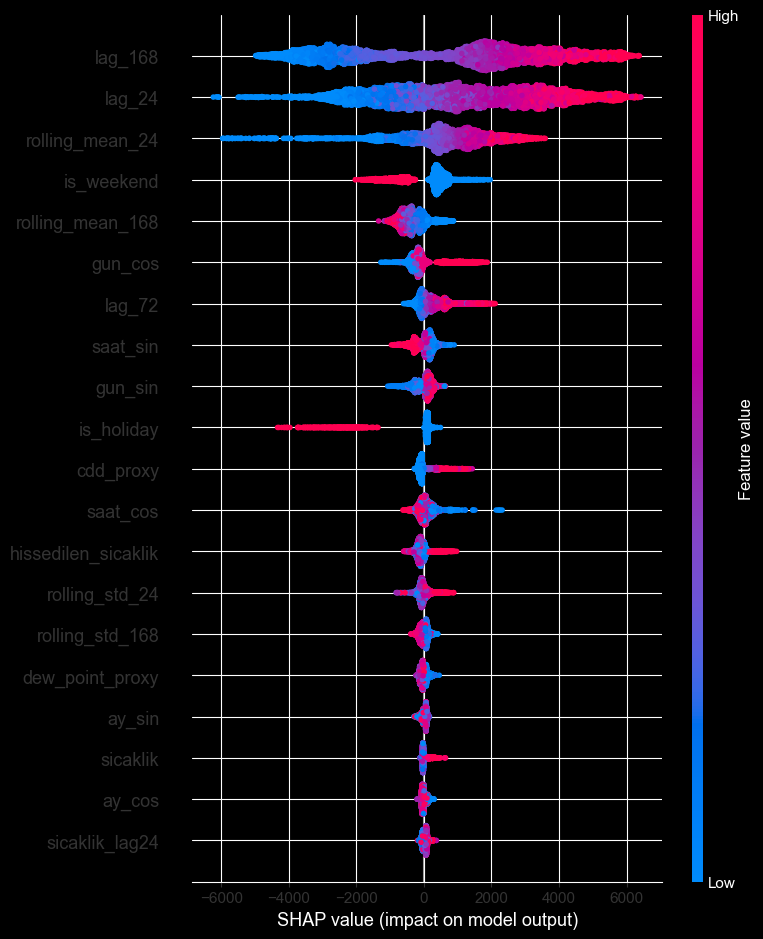

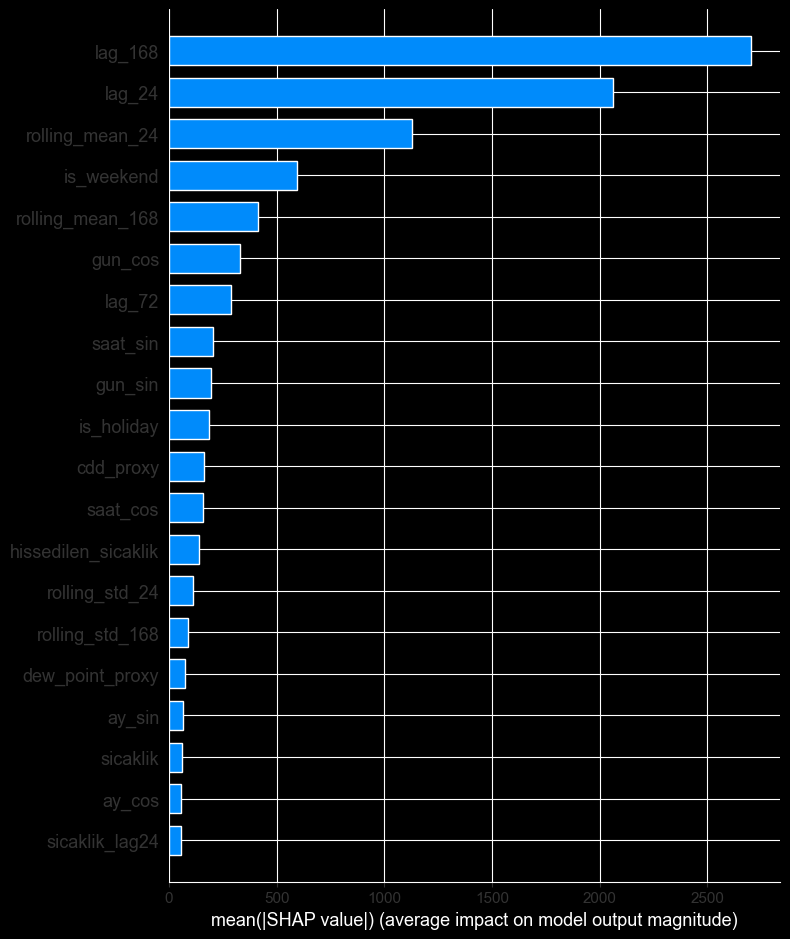

In [18]:
run_shap(pipeline_tuketim, X_test_t, label="Tüketim")

**2) ELEKTRİK FİYATI TAHMİNİ**

In [19]:
df_f = pd.read_csv("C:/Users/kerem/Desktop/EnerjiSon/claude/birlesik_veri.csv")
df_f["Datetime"] = pd.to_datetime(df_f["Datetime"])
df_f = df_f.sort_values("Datetime").set_index("Datetime")

df_f = add_weather_features(df_f)

# net_load: SADECE lagged versiyonu tutuyoruz, t-anı versiyonu leakage
df_f["net_load_lag24"] = (df_f["tuketim_mwh"] - df_f["uretim_mwh"]).shift(24)

In [20]:
def build_fiyat_dataset(csv_path: str) -> pd.DataFrame:
    """
    Fiyat modeli için tüm özellik mühendisliğini tek fonksiyonda toplar.
    2021 fiyat rejimi yapısal kırılma nedeniyle 2022'den itibaren alınıyor.
    """
    df_f = pd.read_csv(csv_path)
    df_f["Datetime"] = pd.to_datetime(df_f["Datetime"])
    df_f = df_f.sort_values("Datetime").set_index("Datetime")

    df_f = add_weather_features(df_f)
    df_f["net_load_lag24"] = (df_f["tuketim_mwh"] - df_f["uretim_mwh"]).shift(24)

    # Fiyat lag / rolling
    df_f["lag_fiyat_24"]           = df_f["fiyat_tl"].shift(24)
    df_f["lag_fiyat_48"]           = df_f["fiyat_tl"].shift(48)
    df_f["lag_fiyat_168"]          = df_f["fiyat_tl"].shift(168)
    df_f["lag_fiyat_336"]          = df_f["fiyat_tl"].shift(336)   # 2 hafta öncesi
    df_f["rolling_fiyat_mean_24"]  = df_f["fiyat_tl"].rolling(24).mean().shift(1)
    df_f["rolling_fiyat_std_24"]   = df_f["fiyat_tl"].rolling(24).std().shift(1)
    df_f["rolling_fiyat_mean_168"] = df_f["fiyat_tl"].rolling(168).mean().shift(1)
    df_f["rolling_fiyat_std_168"]  = df_f["fiyat_tl"].rolling(168).std().shift(1)
    df_f["rolling_fiyat_max_168"]  = df_f["fiyat_tl"].rolling(168).max().shift(1)
    df_f["rolling_price_max_24"]   = df_f["fiyat_tl"].rolling(24).max().shift(1)
    df_f["rolling_price_min_24"]   = df_f["fiyat_tl"].rolling(24).min().shift(1)
    df_f["price_diff_1"]           = df_f["fiyat_tl"].diff(1).shift(1)
    df_f["price_diff_24"]          = df_f["fiyat_tl"].diff(24).shift(1)
    df_f["price_volatility_24"]    = (
        df_f["fiyat_tl"].rolling(24).std()
        / (df_f["fiyat_tl"].rolling(24).mean() + 1e-8)
    ).shift(1)
    df_f["net_load_change_lag24"]  = (
        (df_f["tuketim_mwh"] - df_f["uretim_mwh"]).diff(1).shift(24)
    )
    df_f["lag_tuketim_24"]         = df_f["tuketim_mwh"].shift(24)
    df_f["lag_uretim_24"]          = df_f["uretim_mwh"].shift(24)

    df_f = add_cyclical_features(df_f)
    df_f = df_f[df_f.index >= "2022-01-01"]

    return df_f.dropna()


# ─── FEATURE / TARGET AYIRMA — GELİŞTİRİLMİŞ LEAKAGE KONTROLÜ ──────────────
target_fiyat = "fiyat_tl"
# is_price_spike / is_price_dip t-anı değeri içeriyor → leakage
leakage_cols_f = ["uretim_mwh", "tuketim_mwh", "is_price_spike", "is_price_dip"]
# Sadece var olan sütunları çıkar (eski CSV'lerde olmayabilir)
drop_cols = [target_fiyat] + [c for c in leakage_cols_f if c in df_f.columns]

X_fiyat = df_f.drop(columns=drop_cols)
y_fiyat = df_f[target_fiyat]

In [21]:
def add_price_features_improved(df_f):
    """
    Geliştirilmiş fiyat özellik mühendisliği.
    Mevcut özelliklere ek olarak:
    - lag_fiyat_336: 2 hafta öncesi (haftalık mevsimsellik ikinci harmonik)
    - rolling_fiyat_max_168: haftalık maksimum (spike riski)
    - price_volatility_24: 24 saatlik fiyat volatilitesi
    """
    df_f = df_f.copy()

    # Ek lag özellikler
    df_f["lag_fiyat_336"] = df_f["fiyat_tl"].shift(336)    # 2 hafta öncesi

    # Haftalık rolling max (spike tahmini için)
    df_f["rolling_fiyat_max_168"] = df_f["fiyat_tl"].rolling(168).max().shift(1)

    # Fiyat volatilitesi (yakın dönem dalgalanma)
    df_f["price_volatility_24"] = (
        df_f["fiyat_tl"].rolling(24).std() / (df_f["fiyat_tl"].rolling(24).mean() + 1e-8)
    ).shift(1)   # Coefficient of Variationf

    # Net load değişimi (enerji dengesizliği sinyali)
    df_f["net_load_change_lag24"] = (
        (df_f["tuketim_mwh"] - df_f["uretim_mwh"]).diff(1).shift(24)
    )

    return df_f

In [22]:
df_f = build_fiyat_dataset("C:/Users/kerem/Desktop/EnerjiSon/claude/birlesik_veri.csv")

target_fiyat   = "fiyat_tl"
leakage_cols_f = ["uretim_mwh", "tuketim_mwh"]

X_fiyat = df_f.drop(columns=[target_fiyat] + leakage_cols_f)
y_fiyat = df_f[target_fiyat]

train_mask_f = df_f.index.year <= 2023
val_mask_f   = df_f.index.year == 2024
test_mask_f  = df_f.index.year >= 2025

X_train_f = X_fiyat[train_mask_f]; X_val_f = X_fiyat[val_mask_f]; X_test_f = X_fiyat[test_mask_f]
y_train_f = y_fiyat[train_mask_f]; y_val_f = y_fiyat[val_mask_f]; y_test_f = y_fiyat[test_mask_f]

# DÜZELTME 1 — Fiyat modeli de train+val üzerinde eğitiliyor
# Orijinal: pipeline.fit(X_train_f, y_train_f)  ← yalnızca train
# Düzeltme: pipeline.fit(X_trainval_f, y_trainval_f)
X_trainval_f = pd.concat([X_train_f, X_val_f])
y_trainval_f = pd.concat([y_train_f, y_val_f])

print(f"Fiyat — Train: {X_train_f.shape}  Val: {X_val_f.shape}  Test: {X_test_f.shape}")

Fiyat — Train: (17520, 41)  Val: (8784, 41)  Test: (8760, 41)


In [23]:
cv_results_fiyat = run_cv(models, X_train_f, y_train_f, tscv, sort_by="CV_SMAPE")
print("\nFiyat CV Sonuçları:"); print(cv_results_fiyat.to_string(index=False))

pipeline_fiyat, pred_fiyat, metrics_fiyat_cv = train_best_and_evaluate(
    cv_results_fiyat, models,
    X_trainval_f, y_trainval_f,
    X_test_f, y_test_f,
    label="Fiyat"
)


Fiyat CV Sonuçları:
           Model    CV_RMSE     CV_MAE   CV_MAPE  CV_NRMSE  CV_SMAPE
LinearRegression 377.848288 290.627470 19.914754  9.936364 14.170971
         RidgeCV 381.315813 294.026654 20.470087 10.018112 14.309814
        LightGBM 457.131266 355.841863 21.679979 11.624931 15.988780
GradientBoosting 481.617951 377.939862 22.610961 12.191046 16.804458
    RandomForest 489.456136 381.337418 25.011172 12.467890 17.114668
         XGBoost 493.903163 388.700638 22.958689 12.455963 17.156995
    DecisionTree 572.113452 434.837189 28.473179 14.860017 20.087704

───────────────────────────────────────────────────────
 Fiyat — LinearRegression — Tam Performans Raporu (eps=10 TL filtresi)
───────────────────────────────────────────────────────
  Toplam gözlem  :    8,760
  RMSE           :       351.93
  MAE            :       250.75
  NRMSE          :      10.08%
  MAPE (|y|>10):      31.86%  (8,718 gözlem)
  sMAPE          :      14.99%
────────────────────────────────────────────

In [24]:
def residual_diagnostics(y_true, y_pred, label="Fiyat"):
    """
    Sistematik hata analizi.
    Eğer model belirli saatlerde / aylarda sistematik hata yapıyorsa
    ek özellikler gerekmektedir.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    residuals = y_true - y_pred

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # 1. Hata Dağılımı
    axes[0].hist(residuals, bins=50, color="#2980b9", edgecolor="white", alpha=0.7)
    axes[0].axvline(0, color="red", lw=1.5, ls="--")
    axes[0].set_title(f"{label} — Hata Dağılımı")
    axes[0].set_xlabel("Gerçek − Tahmin (TL/MWh)")
    axes[0].text(0.02, 0.95, f"Ort: {residuals.mean():.1f}\nStd: {residuals.std():.1f}",
                 transform=axes[0].transAxes, va="top", fontsize=9,
                 bbox=dict(boxstyle="round", facecolor="white", alpha=0.5))

    # 2. Gerçek vs Tahmin Scatter
    lim = max(np.abs(y_true).max(), np.abs(y_pred).max()) * 1.05
    axes[1].scatter(y_true, y_pred, alpha=0.2, s=5, color="#c0392b")
    axes[1].plot([0, lim], [0, lim], "k--", lw=1, label="Mükemmel tahmin")
    axes[1].set_xlabel("Gerçek Fiyat (TL/MWh)")
    axes[1].set_ylabel("Tahmin Fiyat (TL/MWh)")
    axes[1].set_title(f"{label} — Gerçek vs Tahmin")
    axes[1].legend(fontsize=8)

    # 3. Hata büyüklüğüne göre gerçek fiyat dağılımı
    # Yüksek fiyatlarda mı daha çok hata yapıyor?
    abs_err = np.abs(residuals)
    axes[2].scatter(y_true, abs_err, alpha=0.2, s=5, color="#8e44ad")
    axes[2].set_xlabel("Gerçek Fiyat (TL/MWh)")
    axes[2].set_ylabel("|Hata| (TL/MWh)")
    axes[2].set_title(f"{label} — Fiyat vs Mutlak Hata")

    # Sistematik önyargı kontrolü
    bias = residuals.mean()
    if abs(bias) > 50:
        print(f"  ⚠️  Sistematik önyargı: {bias:+.1f} TL/MWh — model fiyatı "
              f"{'altında' if bias > 0 else 'üstünde'} tahmin ediyor.")
    else:
        print(f"  ✓ Sistematik önyargı yok (bias={bias:+.1f} TL/MWh)")

    plt.tight_layout()
    plt.savefig(f"residual_diagnostics_{label.lower().replace(' ', '_')}.png",
                bbox_inches="tight", dpi=120)
    plt.show()


───────────────────────────────────────────────────────
 Fiyat — LinearRegression — Tam Performans Raporu (eps=10 TL filtresi)
───────────────────────────────────────────────────────
  Toplam gözlem  :    8,760
  RMSE           :       351.93
  MAE            :       250.75
  NRMSE          :      10.08%
  MAPE (|y|>10):      31.86%  (8,718 gözlem)
  sMAPE          :      14.99%
───────────────────────────────────────────────────────
  Spike Analizi (üst %5, n=438, eşik=3,431):
    RMSE          :       229.14
    sMAPE         :       4.91%
───────────────────────────────────────────────────────
  ⚠️  42 saat ≤10 TL MAPE dışında tutuldu.

───────────────────────────────────────────────────────
 Tüketim — En İyi Model — Tam Performans Raporu (eps=10 TL filtresi)
───────────────────────────────────────────────────────
  Toplam gözlem  :    8,760
  RMSE           :     1,016.68
  MAE            :       688.91
  NRMSE          :       2.67%
  MAPE (|y|>10):       1.73%  (8,760 gözlem)
  

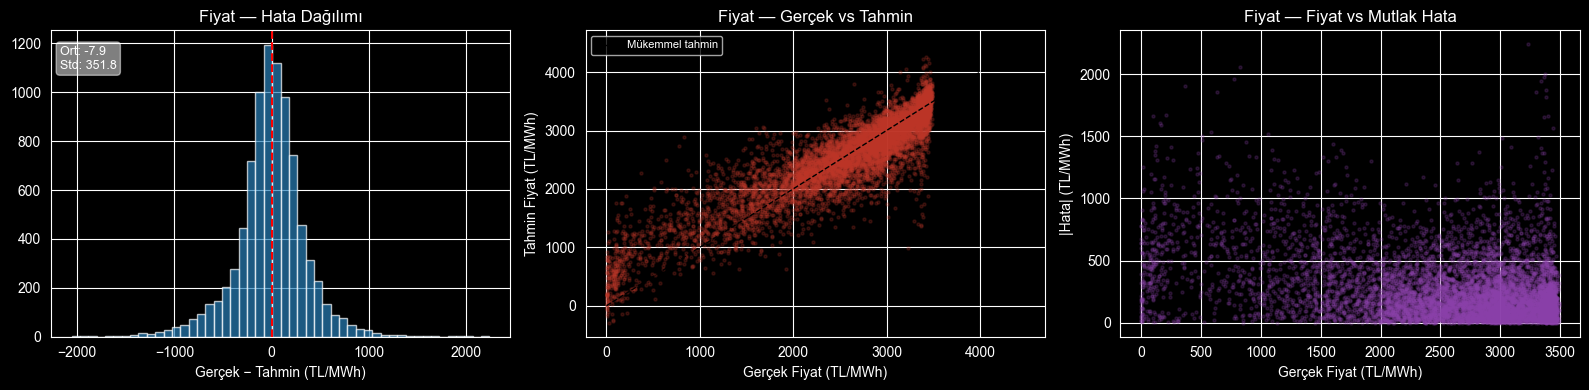

In [25]:
# Tam performans raporu (42 saati HARİÇ TUTMAYAN versiyon)
metrics_fiyat = evaluate_full(y_test_f, pred_fiyat, label="Fiyat — LinearRegression")

# Tüketim için de çalıştır (karşılaştırma)
metrics_tuketim = evaluate_full(y_test_t, pred_tuketim, label="Tüketim — En İyi Model")

# Artık analizi — sistematik hata var mı?
# (residual_diagnostics Cell 28'de tanımlı; önce onu tanımla, sonra bu hücreyi çalıştır)
residual_diagnostics(y_test_f.values, pred_fiyat, label="Fiyat")


[Fiyat] SHAP Summary Plot


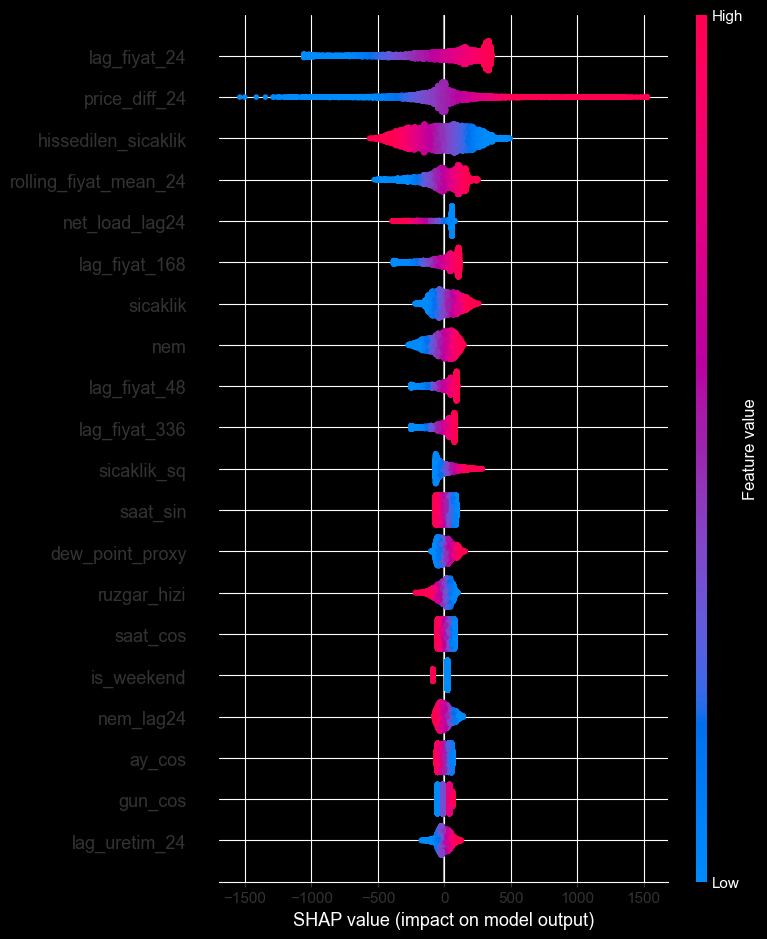

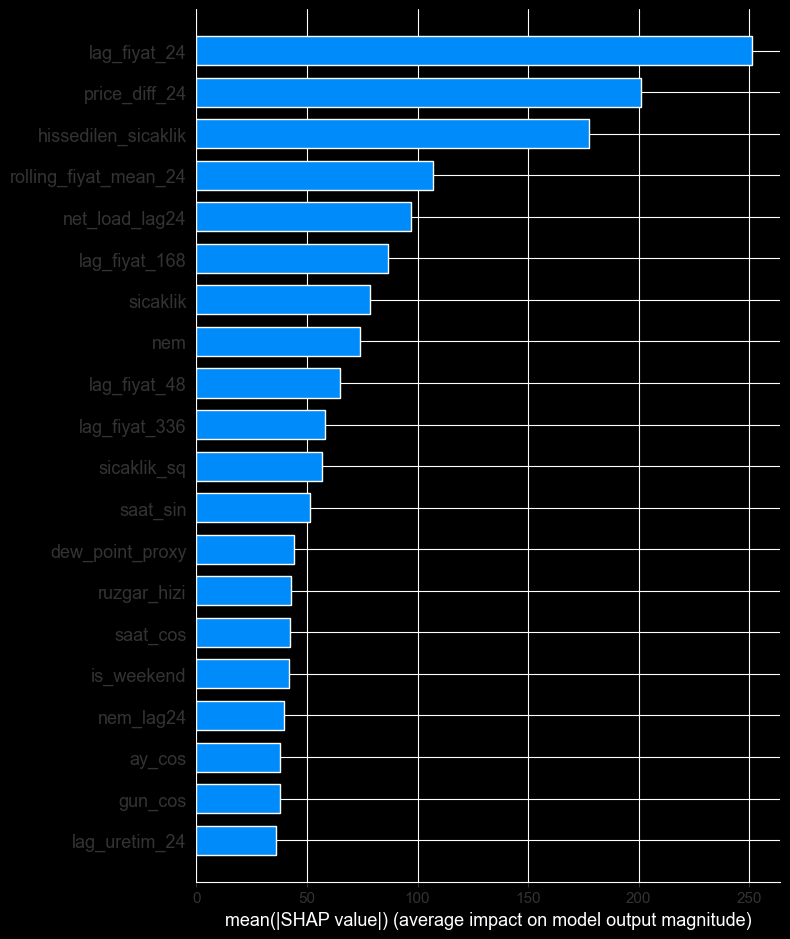

In [26]:
# --- SHAP Analizi ---
run_shap(pipeline_fiyat, X_test_f, label="Fiyat")